In [2]:
# ─────────────────────────────────────────────
# 1. LOAD ALL DATASETS
# ─────────────────────────────────────────────

DATA_PATH = "Dataset/"  # Change to your dataset directory

def load_all_data():
    print("Loading CERT r4.2 Dataset (Sampled)...")

    device       = pd.read_csv(f"{DATA_PATH}device.csv", low_memory=False)
    email = pd.read_csv(f"{DATA_PATH}email.csv",
                    usecols=['id', 'date', 'user', 'pc', 'to', 'attachments'],
                    low_memory=False,
                    skiprows=lambda i: i > 0 and np.random.rand() > 0.50)
    file_df      = pd.read_csv(f"{DATA_PATH}file.csv",   low_memory=False)
    logon        = pd.read_csv(f"{DATA_PATH}logon.csv",  low_memory=False)
    insiders = pd.read_csv("Dataset/insiders.csv", encoding='latin-1')
    psychometric = pd.read_csv(f"{DATA_PATH}psychometric.csv", low_memory=False)

    #http.csv is 14.54GB — sample only 5%
    http = pd.read_csv(f"{DATA_PATH}http.csv",
                   usecols=['id', 'date', 'user', 'pc', 'url'],
                   low_memory=False,
                   skiprows=lambda i: i > 0 and np.random.rand() > 0.20)

    for name, df in [("device", device), ("email", email), ("file", file_df),
                     ("http", http), ("insiders", insiders), ("logon", logon),
                     ("psychometric", psychometric)]:
        print(f"  {name:15s}: {df.shape[0]:>8,} rows")

    return device, email, file_df, http, insiders, logon, psychometric


In [3]:
# ─────────────────────────────────────────────
# 2. PARSE DATES & BASIC CLEANING
# ─────────────────────────────────────────────

def parse_dates(df, col='date'):
    """Parse datetime and extract temporal features."""
    df = df.copy()
    df[col] = pd.to_datetime(df[col], errors='coerce')
    df['hour']       = df[col].dt.hour
    df['day_of_week']= df[col].dt.dayofweek   # 0=Mon, 6=Sun
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    df['is_after_hours'] = ((df['hour'] < 8) | (df['hour'] > 18)).astype(int)
    df['week']       = df[col].dt.isocalendar().week.astype(int)
    df['month']      = df[col].dt.month
    return df


def clean_common(df):
    """Drop duplicates and normalize column names."""
    df.columns = df.columns.str.lower().str.strip()
    df = df.drop_duplicates()
    return df

In [4]:
# ─────────────────────────────────────────────
# 3. PER-SOURCE FEATURE ENGINEERING (MONTHLY)
# ─────────────────────────────────────────────

def process_logon(logon):
    print("\n[LOGON] Processing...")
    logon = clean_common(logon)
    logon = parse_dates(logon, 'date')

    logon['month'] = logon['date'].dt.to_period('M')
    logon['activity_binary'] = (logon['activity'].str.lower() == 'logon').astype(int)

    logon_feat = logon.groupby(['user','month']).agg(
        logon_total=('activity_binary','sum'),
        logon_events=('activity_binary','count'),
        logon_after_hours=('is_after_hours','sum'),
        logon_weekend=('is_weekend','sum'),
        logon_unique_pcs=('pc','nunique'),
        logon_unique_days=('date', lambda x: x.dt.date.nunique()),
        logon_after_hours_ratio=('is_after_hours','mean'),
    ).reset_index()

    logon_feat['logon_rate_per_day'] = (
        logon_feat['logon_total'] / logon_feat['logon_unique_days'].replace(0,1)
    )

    print(f"  logon features shape: {logon_feat.shape}")
    return logon, logon_feat


def process_device(device):
    print("\n[DEVICE] Processing...")
    device = clean_common(device)
    device = parse_dates(device, 'date')

    device['month'] = device['date'].dt.to_period('M')
    device['is_connect'] = (device['activity'].str.lower() == 'connect').astype(int)

    device_feat = device.groupby(['user','month']).agg(
        device_total=('id','count'),
        device_connects=('is_connect','sum'),
        device_after_hours=('is_after_hours','sum'),
        device_weekend=('is_weekend','sum'),
        device_unique_pcs=('pc','nunique'),
        device_after_hours_ratio=('is_after_hours','mean'),
    ).reset_index()

    print(f"  device features shape: {device_feat.shape}")
    return device, device_feat


def process_file(file_df):
    print("\n[FILE] Processing...")
    file_df = clean_common(file_df)
    file_df = parse_dates(file_df, 'date')

    file_df['month'] = file_df['date'].dt.to_period('M')

    sensitive_ext = ['zip','rar','7z','tar','gz','exe','bat','sh','py','sql']
    file_df['filename_lower'] = file_df['filename'].str.lower().fillna('')
    file_df['is_sensitive_ext'] = file_df['filename_lower'].apply(
        lambda x: int(any(x.endswith(f'.{e}') for e in sensitive_ext))
    )

    file_feat = file_df.groupby(['user','month']).agg(
        file_total=('id','count'),
        file_after_hours=('is_after_hours','sum'),
        file_weekend=('is_weekend','sum'),
        file_sensitive=('is_sensitive_ext','sum'),
        file_unique_pcs=('pc','nunique'),
        file_after_hours_ratio=('is_after_hours','mean'),
        file_sensitive_ratio=('is_sensitive_ext','mean'),
    ).reset_index()

    print(f"  file features shape: {file_feat.shape}")
    return file_df, file_feat


def process_email(email):
    print("\n[EMAIL] Processing...")
    email = clean_common(email)
    email = parse_dates(email, 'date')

    email['month'] = email['date'].dt.to_period('M')

    if 'to' in email.columns:
        email['has_external'] = email['to'].fillna('').apply(
            lambda x: int('dtaa.com' not in x.lower())
        )
    else:
        email['has_external'] = 0

    email_feat = email.groupby(['user','month']).agg(
        email_total=('id','count'),
        email_sent_external=('has_external','sum'),
        email_after_hours=('is_after_hours','sum'),
        email_weekend=('is_weekend','sum'),
        email_after_hours_ratio=('is_after_hours','mean'),
        email_external_ratio=('has_external','mean'),
    ).reset_index()

    if 'attachments' in email.columns:
        att_feat = email.groupby(['user','month'])['attachments'].agg(
            email_total_attachments='sum',
            email_avg_attachments='mean'
        ).reset_index()
        email_feat = email_feat.merge(att_feat, on=['user','month'], how='left')

    print(f"  email features shape: {email_feat.shape}")
    return email, email_feat


def process_http(http):
    print("\n[HTTP] Processing...")
    http = clean_common(http)
    http = parse_dates(http, 'date')

    http['month'] = http['date'].dt.to_period('M')

    leak_keywords = ['wikileaks','pastebin','ghostbin','hastebin','dpaste']
    cloud_keywords= ['dropbox','drive.google','onedrive','box.com','mega.nz']
    job_keywords  = ['linkedin','monster','indeed','glassdoor','careerbuilder']

    def classify_url(url):
        if pd.isna(url): return 'other'
        url = url.lower()
        if any(k in url for k in leak_keywords): return 'leak_site'
        if any(k in url for k in cloud_keywords): return 'cloud_storage'
        if any(k in url for k in job_keywords): return 'job_search'
        return 'other'

    http['url_category'] = http['url'].apply(classify_url)

    http_feat = http.groupby(['user','month']).agg(
        http_total=('id','count'),
        http_after_hours=('is_after_hours','sum'),
        http_weekend=('is_weekend','sum'),
        http_after_hours_ratio=('is_after_hours','mean'),
    ).reset_index()

    cat_pivot = http.groupby(['user','month','url_category']).size().unstack(fill_value=0).reset_index()
    cat_pivot.columns = ['user','month'] + [f'http_{c}' for c in cat_pivot.columns[2:]]

    http_feat = http_feat.merge(cat_pivot, on=['user','month'], how='left')

    print(f"  http features shape: {http_feat.shape}")
    return http, http_feat


def process_psychometric(psychometric):
    print("\n[PSYCHOMETRIC] Processing...")
    psychometric.columns = psychometric.columns.str.lower().str.strip()
    psychometric = psychometric.rename(columns={'user_id': 'user'})
    psychometric = psychometric[['user','o','c','e','a','n']]
    print(f"  psychometric features shape: {psychometric.shape}")
    return psychometric


def process_insiders(insiders):
    print("\n[INSIDERS] Processing...")
    insiders.columns = insiders.columns.str.lower().str.strip()
    insiders['is_insider'] = 1
    insiders = insiders[['user','is_insider','scenario']].drop_duplicates(subset='user')
    print(f"  Total insider users: {insiders['user'].nunique()}")
    return insiders

In [5]:
# ─────────────────────────────────────────────
# 4. MERGE ALL FEATURES INTO MASTER TABLE
# ─────────────────────────────────────────────

def merge_features(logon_feat, device_feat, file_feat,
                   email_feat, http_feat, psychometric, insiders):

    print("\n[MERGING FEATURES]")

    master = logon_feat.copy()

    for feat_df, name in [
        (device_feat, 'device'),
        (file_feat, 'file'),
        (email_feat, 'email'),
        (http_feat, 'http'),
    ]:
        master = master.merge(feat_df, on=['user','month'], how='left')
        print(f"  After merging {name:15s}: {master.shape}")

    master = master.merge(psychometric, on='user', how='left')
    print(f"  After merging psychometric : {master.shape}")

    master = master.merge(insiders[['user','is_insider','scenario']],
                          on='user', how='left')

    master['is_insider'] = master['is_insider'].fillna(0)

    print(f"  Final master shape: {master.shape}")

    return master

In [6]:
# ─────────────────────────────────────────────
# 5. CLEAN, ENCODE & SCALE
# ─────────────────────────────────────────────

def final_preprocessing(master):
    print("\n[PREPROCESSING] Cleaning & encoding...")

    # Fill missing numeric columns with 0
    num_cols = master.select_dtypes(include=[np.number]).columns.tolist()
    master[num_cols] = master[num_cols].fillna(0)

    # Encode scenario
    le = LabelEncoder()
    master['scenario'] = master['scenario'].fillna('none').astype(str)
    master['scenario_encoded'] = le.fit_transform(master['scenario'])

    #DROP NON-FEATURE COLUMNS (INCLUDING MONTH)
    drop_cols = ['user', 'month', 'scenario', 'scenario_encoded', 'is_insider']

    feature_cols = [c for c in master.columns if c not in drop_cols]

    X = master[feature_cols].copy()
    y = master['is_insider']

    # Handle any remaining object columns safely
    obj_cols = X.select_dtypes(include='object').columns
    for col in obj_cols:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))

    print(f"  Feature matrix : {X.shape}")
    print(f"  Class balance  : {dict(y.value_counts())}")

    return X, y, master, feature_cols

In [7]:
# ─────────────────────────────────────────────
# 6. TRAIN/TEST SPLIT WITH STRATIFICATION
# ─────────────────────────────────────────────

def split_data(X, y, test_size=0.2, random_state=42):
    print("\n[SPLIT] Creating train/test splits...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )
    print(f"  Train: {X_train.shape} | Insider rate: {y_train.mean():.3f}")
    print(f"  Test : {X_test.shape}  | Insider rate: {y_test.mean():.3f}")
    return X_train, X_test, y_train, y_test

In [8]:
# ─────────────────────────────────────────────
# 7. MAIN PIPELINE
# ─────────────────────────────────────────────

def main():
    # Load
    device, email, file_df, http, insiders, logon, psychometric = load_all_data()

    # Process each source
    logon,   logon_feat   = process_logon(logon)
    device,  device_feat  = process_device(device)
    file_df, file_feat    = process_file(file_df)
    email,   email_feat   = process_email(email)
    http,    http_feat    = process_http(http)
    psychometric          = process_psychometric(psychometric)
    insiders              = process_insiders(insiders)

    # Merge
    master = merge_features(logon_feat, device_feat, file_feat,
                            email_feat, http_feat, psychometric, insiders)

    # Final preprocessing
    X, y, master_df, feature_cols = final_preprocessing(master)
    
    # ─────────────────────────────────────────────
    # USER-LEVEL TRAIN/TEST SPLIT (NO LEAKAGE)
    # ─────────────────────────────────────────────
    
    unique_users = master_df['user'].unique()
    
    train_users, test_users = train_test_split(
        unique_users,
        test_size=0.2,
        random_state=42
    )
    
    train_mask = master_df['user'].isin(train_users)
    test_mask  = master_df['user'].isin(test_users)
    
    X_train = X[train_mask]
    X_test  = X[test_mask]
    
    y_train = y[train_mask]
    y_test  = y[test_mask]
    
    print("\n[SPLIT - USER LEVEL]")
    print(f"Train shape: {X_train.shape}")
    print(f"Test shape : {X_test.shape}")
    print(f"Train insider rate: {y_train.mean():.4f}")
    print(f"Test insider rate : {y_test.mean():.4f}")
        
    # Now scale
    scaler = StandardScaler()
    
    X_train = pd.DataFrame(
        scaler.fit_transform(X_train),
        columns=X.columns,
        index=X_train.index
    )
    
    X_test = pd.DataFrame(
        scaler.transform(X_test),
        columns=X.columns,
        index=X_test.index
    )


    # Save outputs
    master_df.to_csv("master_features.csv", index=False)
    X_train.to_csv("X_train.csv", index=False)
    X_test.to_csv("X_test.csv",  index=False)
    y_train.to_csv("y_train.csv", index=False)
    y_test.to_csv("y_test.csv",  index=False)

    print("\n" + "=" * 60)
    print("Preprocessing complete! Saved:")
    print("  master_features.csv  - Full engineered feature table")
    print("  X_train/X_test.csv   - Scaled feature matrices")
    print("  y_train/y_test.csv   - Labels (1=insider, 0=normal)")
    print("=" * 60)

    return X_train, X_test, y_train, y_test, master_df, scaler, feature_cols



if __name__ == "__main__":
    X_train, X_test, y_train, y_test, master_df, scaler, feature_cols = main()

Loading CERT r4.2 Dataset (Sampled)...
  device         :  405,380 rows
  email          : 1,314,573 rows
  file           :  445,581 rows
  http           : 2,306,416 rows
  insiders       :      191 rows
  logon          :  854,859 rows
  psychometric   :    1,000 rows

[LOGON] Processing...
  logon features shape: (15899, 10)

[DEVICE] Processing...
  device features shape: (3547, 8)

[FILE] Processing...
  file features shape: (3532, 9)

[EMAIL] Processing...
  email features shape: (15899, 10)

[HTTP] Processing...
  http features shape: (6895, 10)

[PSYCHOMETRIC] Processing...
  psychometric features shape: (1000, 6)

[INSIDERS] Processing...
  Total insider users: 191

[MERGING FEATURES]
  After merging device         : (15899, 16)
  After merging file           : (15899, 23)
  After merging email          : (15899, 31)
  After merging http           : (15899, 39)
  After merging psychometric : (15899, 44)
  Final master shape: (15899, 46)

[PREPROCESSING] Cleaning & encoding...

In [9]:
print("Label distribution:")
print(master_df['is_insider'].value_counts())
print(f"\nInsider users: {master_df[master_df['is_insider']==1]['user'].nunique() if 'user' in master_df.columns else 'N/A'}")
print(f"Scenario breakdown:\n{master_df[master_df['is_insider']==1]['scenario'].value_counts()}")

Label distribution:
is_insider
0.0    15139
1.0      760
Name: count, dtype: int64

Insider users: 70
Scenario breakdown:
scenario
2.0    343
1.0    324
3.0     93
Name: count, dtype: int64


In [10]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
is_insider
0.0    12140
1.0      628
Name: count, dtype: int64

Testing class distribution:
is_insider
0.0    2999
1.0     132
Name: count, dtype: int64


In [11]:
print("[MODEL] Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Training Complete")

[MODEL] Training Random Forest...
Training Complete


In [12]:
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== ROC-AUC Score ===")
print(roc_auc_score(y_test, y_proba))


=== Classification Report ===
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98      2999
         1.0       1.00      0.20      0.33       132

    accuracy                           0.97      3131
   macro avg       0.98      0.60      0.66      3131
weighted avg       0.97      0.97      0.96      3131


=== Confusion Matrix ===
[[2999    0]
 [ 106   26]]

=== ROC-AUC Score ===
0.7475357947598694


In [13]:
# ────────────────
# Step: Apply custom threshold
# ────────────────

# Set your custom threshold (e.g., 0.3 for more sensitive detection)
threshold = 0.3
y_pred_custom = (y_proba >= threshold).astype(int)

print("\n=== Classification Report (Custom Threshold) ===")
print(classification_report(y_test, y_pred_custom))

print("\n=== Confusion Matrix (Custom Threshold) ===")
print(confusion_matrix(y_test, y_pred_custom))


=== Classification Report (Custom Threshold) ===
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98      2999
         1.0       0.86      0.23      0.36       132

    accuracy                           0.97      3131
   macro avg       0.91      0.61      0.67      3131
weighted avg       0.96      0.97      0.96      3131


=== Confusion Matrix (Custom Threshold) ===
[[2994    5]
 [ 102   30]]


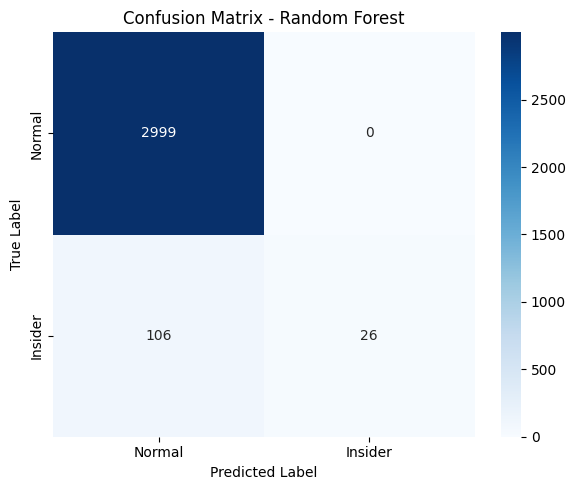

In [14]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, 
                annot=True, 
                fmt='d', 
                cmap='Blues',
                xticklabels=['Normal', 'Insider'],
                yticklabels=['Normal', 'Insider'])
    
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_test, y_pred, "Random Forest")

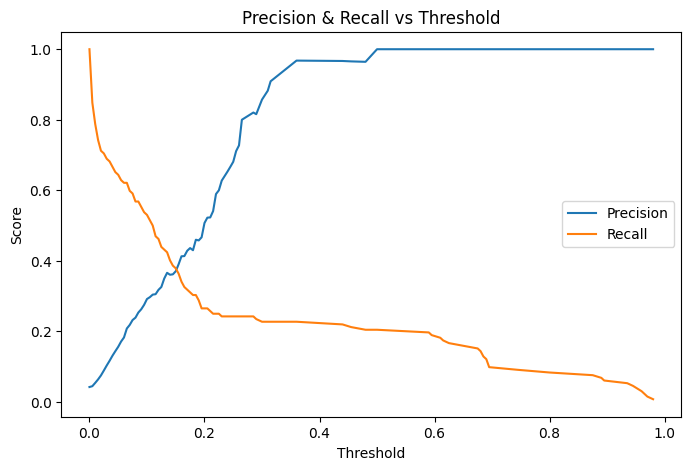

In [15]:
# Precision-Recall Curve
prec, rec, thresh = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8,5))
plt.plot(thresh, prec[:-1], label='Precision')
plt.plot(thresh, rec[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision & Recall vs Threshold')
plt.legend()
plt.show()

In [16]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(10)

o                     0.063193
a                     0.059156
device_total          0.057756
e                     0.052057
file_total            0.049497
c                     0.047219
device_connects       0.045840
n                     0.043023
logon_rate_per_day    0.041009
logon_events          0.039159
dtype: float64

In [17]:
top_features = importances.sort_values(ascending=False).head(10)
print("Top 10 features for insider detection:\n", top_features)

Top 10 features for insider detection:
 o                     0.063193
a                     0.059156
device_total          0.057756
e                     0.052057
file_total            0.049497
c                     0.047219
device_connects       0.045840
n                     0.043023
logon_rate_per_day    0.041009
logon_events          0.039159
dtype: float64


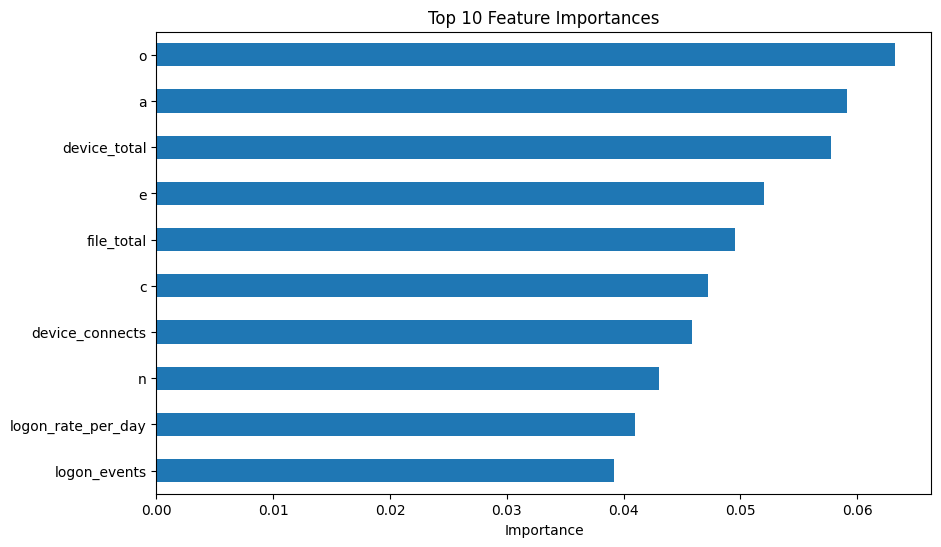

In [18]:
plt.figure(figsize=(10,6))
top_features.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.show()

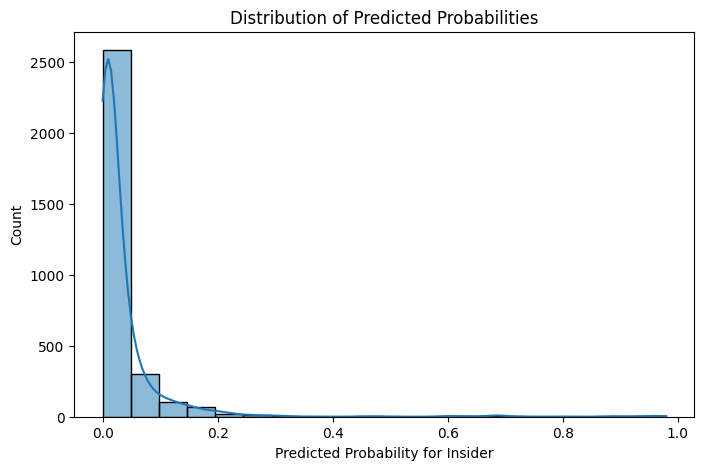

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(y_proba, bins=20, kde=True)
plt.xlabel("Predicted Probability for Insider")
plt.ylabel("Count")
plt.title("Distribution of Predicted Probabilities")
plt.show()

In [20]:
pred_df = pd.DataFrame({
    'user': master_df.loc[y_test.index, 'user'],
    'true_label': y_test,
    'probability': y_proba,
    'pred_default': y_pred,
    'pred_custom': y_pred_custom
})

# False negatives (missed insiders)
fn = pred_df[(pred_df['true_label']==1) & (pred_df['pred_custom']==0)]
print("False Negatives (Insiders missed):")
print(fn)

# False positives (normal users flagged as insider)
fp = pred_df[(pred_df['true_label']==0) & (pred_df['pred_custom']==1)]
print("\nFalse Positives (Normal users flagged):")
print(fp)

False Negatives (Insiders missed):
          user  true_label  probability  pred_default  pred_custom
1538   BBS0039         1.0        0.190           0.0            0
1539   BBS0039         1.0        0.185           0.0            0
1540   BBS0039         1.0        0.120           0.0            0
1541   BBS0039         1.0        0.160           0.0            0
1542   BBS0039         1.0        0.155           0.0            0
...        ...         ...          ...           ...          ...
14549  TNM0961         1.0        0.100           0.0            0
14550  TNM0961         1.0        0.115           0.0            0
14551  TNM0961         1.0        0.140           0.0            0
14552  TNM0961         1.0        0.110           0.0            0
14553  TNM0961         1.0        0.160           0.0            0

[102 rows x 5 columns]

False Positives (Normal users flagged):
          user  true_label  probability  pred_default  pred_custom
5515   GBM0603         0.0   

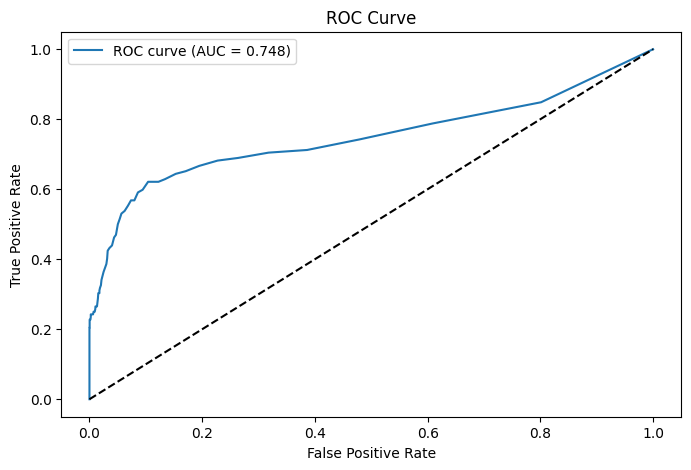

In [21]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [22]:
joblib.dump(rf_model, 'rf_insider_model.pkl')
joblib.dump(threshold, 'rf_threshold.pkl')
joblib.dump(scaler, 'rf_scaler.pkl')
joblib.dump(feature_cols, 'rf_features.pkl')

print("All objects saved successfully!")

All objects saved successfully!


In [23]:
def predict_new_users(new_df):
    """
    Predict insiders for new data.
    new_df: raw logon/device/file/email/http/psychometric/insiders data merged similarly to master_df
    Returns: DataFrame with user, predicted label, probability
    """
    # Load preprocessing objects
    rf_model = joblib.load('rf_insider_model.pkl')
    threshold = joblib.load('rf_threshold.pkl')
    scaler = joblib.load('rf_scaler.pkl')
    feature_cols = joblib.load('rf_features.pkl')
    
    # Preprocess: fill missing numeric columns
    num_cols = new_df.select_dtypes(include=[np.number]).columns.tolist()
    new_df[num_cols] = new_df[num_cols].fillna(0)
    
    # Encode object columns
    obj_cols = new_df.select_dtypes(include='object').columns
    for col in obj_cols:
        new_df[col] = new_df[col].astype(str).factorize()[0]

    # Ensure all required columns exist
    missing_cols = set(feature_cols) - set(new_df.columns)
    for col in missing_cols:
        new_df[col] = 0
        
    # Keep only training features
    X_new = new_df[feature_cols]
    
    # Scale
    X_new_scaled = pd.DataFrame(scaler.transform(X_new), columns=X_new.columns)
    
    # Predict probabilities
    proba = rf_model.predict_proba(X_new_scaled)[:, 1]
    
    # Apply custom threshold
    pred = (proba >= threshold).astype(int)
    
    result = pd.DataFrame({
        'user': new_df['user'],
        'predicted_label': pred,
        'probability': proba
    })
    
    return result

In [24]:
# Assuming master_df exists
# Number of new users you want to simulate
n_new_users = 50

# Sample random users from existing data as template
template = master_df.sample(n=n_new_users, replace=True, random_state=42).reset_index(drop=True)

# Create new user IDs
template['user'] = ['new_user_' + str(i) for i in range(n_new_users)]

# Slightly perturb numeric features to simulate new activity
num_cols = template.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ['is_insider', 'scenario_encoded']]  # keep target unchanged

for col in num_cols:
    # Add small random noise
    template[col] = template[col] * np.random.uniform(0.8, 1.2, size=n_new_users)
    # Ensure no negative values
    template[col] = template[col].clip(lower=0)

# For object/categorical columns
obj_cols = template.select_dtypes(include='object').columns.tolist()
obj_cols = [c for c in obj_cols if c != 'user']

for col in obj_cols:
    template[col] = template[col].sample(frac=1.0, replace=True, random_state=42).values

# Set target columns to 0 (unknown for new data)
template['is_insider'] = 0
template['scenario'] = 'none'
template['scenario_encoded'] = 0

# Save as new_master_df
new_master_df = template.copy()

print("New synthetic dataset created:")
print(new_master_df.head())
print(f"Shape: {new_master_df.shape}")

New synthetic dataset created:
         user    month  logon_total  logon_events  logon_after_hours  \
0  new_user_0  2010-01    38.136919     63.992371           0.000000   
1  new_user_1  2011-04    17.337163     36.723897          24.178147   
2  new_user_2  2010-07    19.194056     44.826489           0.000000   
3  new_user_3  2010-03    23.037419     36.863972           9.871697   
4  new_user_4  2010-08    17.632684     35.855301           0.000000   

   logon_weekend  logon_unique_pcs  logon_unique_days  \
0       4.795144          3.791975          25.029229   
1       0.000000          1.871007          21.377595   
2       0.000000          0.868427          18.274665   
3       0.000000          1.058040          24.585888   
4       0.000000          0.869870          20.262554   

   logon_after_hours_ratio  logon_rate_per_day  ...  http_leak_site  \
0                 0.000000            1.940250  ...             0.0   
1                 0.418861            0.866401  ...

In [25]:
# ─────────────────────────────────────────────
# Step: Predict insiders on new synthetic dataset
# ─────────────────────────────────────────────

# Make sure new_master_df exists
try:
    new_predictions = predict_new_users(new_master_df)
except NameError:
    print("Error: 'new_master_df' not found. Run the synthetic dataset creation first.")

# Show top 10 predicted insiders sorted by probability
top_suspicious = new_predictions.sort_values(by='probability', ascending=False).head(10)

print("\nTop suspicious users in new dataset:")
print(top_suspicious)


Top suspicious users in new dataset:
    user  predicted_label  probability
3      3                1        0.775
40    40                0        0.270
30    30                0        0.105
45    45                0        0.090
37    37                0        0.085
20    20                0        0.080
12    12                0        0.075
2      2                0        0.055
36    36                0        0.050
24    24                0        0.050


In [26]:
new_predictions.to_csv("new_predictions.csv", index=False)

In [27]:
# Count predicted insiders vs normal users
print(new_predictions['predicted_label'].value_counts())

# Inspect top users by probability
print(new_predictions.sort_values(by='probability', ascending=False).head(20))

# Inspect low-confidence predictions
print(new_predictions.sort_values(by='probability', ascending=True).head(20))

predicted_label
0    49
1     1
Name: count, dtype: int64
    user  predicted_label  probability
3      3                1        0.775
40    40                0        0.270
30    30                0        0.105
45    45                0        0.090
37    37                0        0.085
20    20                0        0.080
12    12                0        0.075
2      2                0        0.055
36    36                0        0.050
24    24                0        0.050
15    15                0        0.045
8      8                0        0.045
21    21                0        0.040
14    14                0        0.040
34    34                0        0.030
33    33                0        0.030
13    13                0        0.025
5      5                0        0.025
42    42                0        0.025
22    22                0        0.025
    user  predicted_label  probability
0      0                0        0.000
9      9                0        0.000
10    

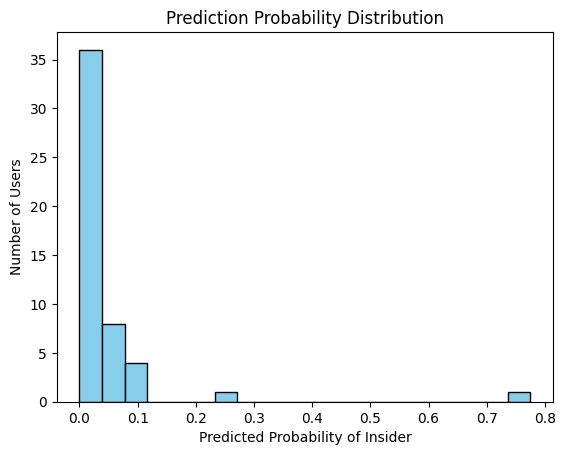

In [28]:
plt.hist(new_predictions['probability'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Predicted Probability of Insider')
plt.ylabel('Number of Users')
plt.title('Prediction Probability Distribution')
plt.show()

In [29]:
# Count of predicted insiders vs normal users
print("Predicted user distribution:")
print(new_predictions['predicted_label'].value_counts())

# Top suspicious users by probability
top_suspicious = new_predictions.sort_values(by='probability', ascending=False).head(10)
print("\nTop suspicious users:")
print(top_suspicious)

Predicted user distribution:
predicted_label
0    49
1     1
Name: count, dtype: int64

Top suspicious users:
    user  predicted_label  probability
3      3                1        0.775
40    40                0        0.270
30    30                0        0.105
45    45                0        0.090
37    37                0        0.085
20    20                0        0.080
12    12                0        0.075
2      2                0        0.055
36    36                0        0.050
24    24                0        0.050


In [30]:
new_predictions.to_csv("new_predictions.csv", index=False)

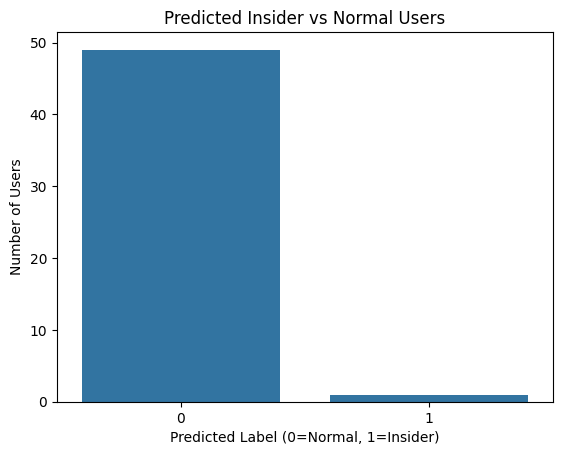

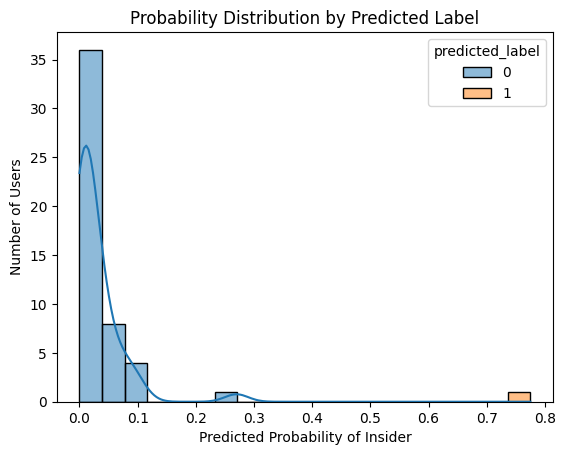

In [31]:
sns.countplot(x='predicted_label', data=new_predictions)
plt.xlabel('Predicted Label (0=Normal, 1=Insider)')
plt.ylabel('Number of Users')
plt.title('Predicted Insider vs Normal Users')
plt.show()

# Probability distribution by predicted label
sns.histplot(data=new_predictions, x='probability', hue='predicted_label', bins=20, kde=True)
plt.xlabel('Predicted Probability of Insider')
plt.ylabel('Number of Users')
plt.title('Probability Distribution by Predicted Label')
plt.show()

In [32]:
high_risk = new_predictions[new_predictions['probability'] >= 0.8]  # threshold of 0.8
high_risk.to_csv("high_risk_users.csv", index=False)
print(f"High-risk users saved: {len(high_risk)}")

High-risk users saved: 0


In [33]:
print(new_predictions['predicted_label'].value_counts())

predicted_label
0    49
1     1
Name: count, dtype: int64


In [34]:
top_suspicious = new_predictions.sort_values(by='probability', ascending=False).head(10)
print(top_suspicious)

    user  predicted_label  probability
3      3                1        0.775
40    40                0        0.270
30    30                0        0.105
45    45                0        0.090
37    37                0        0.085
20    20                0        0.080
12    12                0        0.075
2      2                0        0.055
36    36                0        0.050
24    24                0        0.050


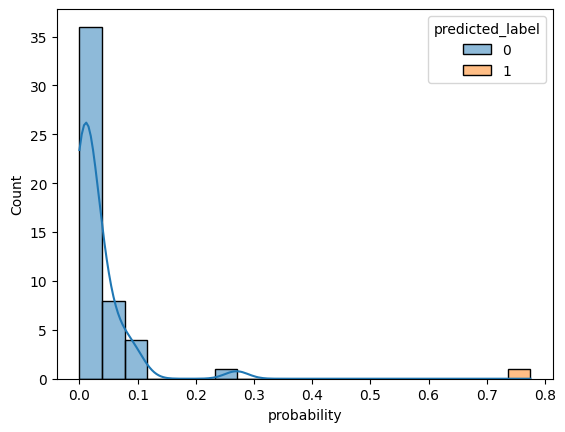

In [35]:
sns.histplot(data=new_predictions, x='probability', hue='predicted_label', bins=20, kde=True)
plt.show()

In [36]:
high_risk = new_predictions[new_predictions['probability'] >= 0.8]
high_risk.to_csv("high_risk_users.csv", index=False)